# Lab 5: Writing data into PostgreSQL tables

Santiago Elí Jiménez Aguilar
Luis Eduardo Gonzalez Gloria

## Goal:
The goal of this lab is to practice how to persist data into a relational database
(PostgreSQL) as a storage solution within a Big Data pipeline.

## Instructions
- Create a Jupyter Notebook to read the movies dataset.
- Use one of the Data Frames generated in the EDA activity and write it into
PosgreSQL.
- Once information is written, read a new DataFrame from the table you stored
in PostgreSQL.
- Finally, export the Notebook as PDF (first as HTML and then export it as PDF)
- Upload the PDF document to Canvas

In [1]:
from spark_utils import SparkUtils

su = SparkUtils("Lab 5: Writing data into PostgreSQL tables",
                "spark://spark-master:7077",
                spark_jars="/opt/spark/work-dir/notebooks/jars/postgresql-42.7.10.jar ")
su.spark

26/03/19 01:07:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


### Create DataFrames

In [2]:
import pyspark.sql.functions as F
movies_columns = [("MovieID", "int"),
                  ("Title", "string"),
                  ("Genre", "string"),
                  ("ReleaseYear", "int"),
                  ("ReleaseDate_Str", "string"),
                  ("Country", "string"),
                  ("BudgetUSD", "float"),
                  ("US_BoxOfficeUSD", "float"),
                  ("Global_BoxOfficeUSD", "float"),
                  ("Opening_Day_SalesUSD", "float"),
                  ("One_Week_SalesUSD", "float"),
                  ("IMDbRating", "float"),
                  ("RottenTomatoesScore", "float"),
                  ("NumVotesIMDb", "int"),
                  ("NumVotesRT", "int"),
                  ("Director", "string"),
                  ("LeadActor", "string")]

movies_schema = SparkUtils.generate_schema(movies_columns)

movies_date_str_df = (su.spark.read 
                .option("header", "true")
                .schema(movies_schema)
                .csv("/opt/spark/work-dir/data/movies"))

In [3]:
from pyspark.sql.functions import to_date
movies_df = movies_date_str_df.withColumn("ReleaseDate", to_date("ReleaseDate_Str", "dd-MM-yyyy")).drop("ReleaseDate_Str")

In [4]:
movies_df.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genre: string (nullable = true)
 |-- ReleaseYear: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- BudgetUSD: float (nullable = true)
 |-- US_BoxOfficeUSD: float (nullable = true)
 |-- Global_BoxOfficeUSD: float (nullable = true)
 |-- Opening_Day_SalesUSD: float (nullable = true)
 |-- One_Week_SalesUSD: float (nullable = true)
 |-- IMDbRating: float (nullable = true)
 |-- RottenTomatoesScore: float (nullable = true)
 |-- NumVotesIMDb: integer (nullable = true)
 |-- NumVotesRT: integer (nullable = true)
 |-- Director: string (nullable = true)
 |-- LeadActor: string (nullable = true)
 |-- ReleaseDate: date (nullable = true)



In [5]:
import matplotlib.pyplot as plt

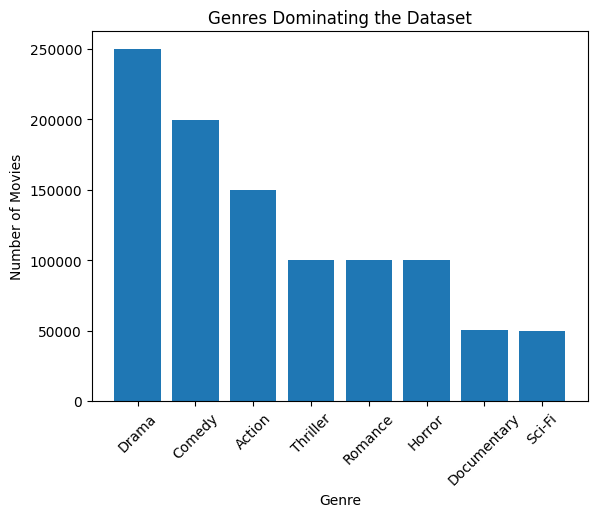

In [6]:
sdf = (movies_df
    .groupBy("Genre")
    .count()
    .orderBy(F.col("count"), ascending=False)
    .limit(10))

pdf = sdf.toPandas()

plt.figure()
plt.bar(pdf["Genre"], pdf["count"])
plt.title("Genres Dominating the Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

### Save DataFrame into PostgreSQ

In [7]:
jdbc_url = "jdbc:postgresql://postgres-iteso:5432/postgres"
table_name = "genres_that_dominate_movies"

sdf.write \
    .format("jdbc") \
    .option("url", jdbc_url) \
    .option("dbtable", table_name) \
    .option("user", "postgres") \
    .option("password", "Admin@1234") \
    .option("driver", "org.postgresql.Driver") \
    .mode("overwrite") \
    .save()

print("DataFrame successfully written into a PosgreSQL DB !")

Py4JJavaError: An error occurred while calling o77.save.
: org.postgresql.util.PSQLException: The connection attempt failed.
	at org.postgresql.core.v3.ConnectionFactoryImpl.openConnectionImpl(ConnectionFactoryImpl.java:385)
	at org.postgresql.core.ConnectionFactory.openConnection(ConnectionFactory.java:57)
	at org.postgresql.jdbc.PgConnection.<init>(PgConnection.java:290)
	at org.postgresql.Driver.makeConnection(Driver.java:448)
	at org.postgresql.Driver.connect(Driver.java:298)
	at org.apache.spark.sql.execution.datasources.jdbc.connection.BasicConnectionProvider.getConnection(BasicConnectionProvider.scala:50)
	at org.apache.spark.sql.execution.datasources.jdbc.connection.ConnectionProviderBase.create(ConnectionProvider.scala:102)
	at org.apache.spark.sql.jdbc.JdbcDialect.$anonfun$createConnectionFactory$1(JdbcDialects.scala:235)
	at org.apache.spark.sql.jdbc.JdbcDialect.$anonfun$createConnectionFactory$1$adapted(JdbcDialects.scala:231)
	at org.apache.spark.sql.execution.datasources.

### Read DataFrame from PostgreSQ

In [ ]:
jdbc_url = "jdbc:postgresql://postgres-iteso:5432/postgres"
db_properties = {
      "user": "postgres",      
      "password": "Admin@1234",
      "driver": "org.postgresql.Driver"
  }

df = (su.spark.read
    .jdbc(url=jdbc_url, table=table_name, properties=db_properties))

df.printSchema()
df.show(truncate=False)

### Turn df into Pandas

In [ ]:
pdf = df.toPandas().sort_values("count", ascending=False)

plt.figure()
plt.bar(pdf["Genre"], pdf["count"])
plt.title("Genres Dominating the Dataset (from PostgreSQL)")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
su.spark.stop()